Name:   Srujana Duggineni

ID:     C00313483

**Algorithm:  RNN (Hyperparameter tunning)**

*Dataset: Amazon Reviews Dataset (Twitter Sentiment Analysis Dataset)*
https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv


#### 1. Business Understanding:

The objective of this work is to develop an optimized Recurrent Neural Network (RNN)-based text classification model for sentiment analysis using the Amazon Reviews dataset. The objective is to explore various architectural and hyperparameter tuning approaches to enhance model performance, generalize better, and minimize overfitting.

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_hub as hub
import tensorflow_text as text
from tensorflow.keras.layers import Layer, Input, Dense, SimpleRNN,Lambda
# Function to plot training history
def plot_training(history, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'{model_name} - Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'{model_name} - Loss')

    plt.show()

#### 2. Data Preprocessing:

In [2]:
# RNN - Sentiment Analysis (Amazon Reviews using Pretrained Embeddings)
print("\nLoading Amazon Reviews Dataset for RNN...")
amazon_data = pd.read_csv("https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv")
text_data = amazon_data['tweet'].astype(str).values
target_data = amazon_data['label'].values

train_x, test_x, train_y, test_y = train_test_split(text_data, target_data, test_size=0.2, random_state=42)
embedding_layer = hub.KerasLayer("https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim/1", trainable=False)


Loading Amazon Reviews Dataset for RNN...


#### 3. Baseline Model (Initial Model)

Initial Hyperparameters:
- RNN Units: 64 per layer.
-	Epochs: 10 (configurable).
-	Batch Size: 32.
-	Loss Function: Binary Cross-Entropy for sentiment classification.
-	Activation Function: Sigmoid in the output layer for binary classification.


Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9148 - loss: 0.2355 - val_accuracy: 0.9296 - val_loss: 0.2033
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9299 - loss: 0.1962 - val_accuracy: 0.9295 - val_loss: 0.2003
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9342 - loss: 0.1835 - val_accuracy: 0.9327 - val_loss: 0.2066
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9334 - loss: 0.1841 - val_accuracy: 0.9313 - val_loss: 0.1967
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9356 - loss: 0.1861 - val_accuracy: 0.9340 - val_loss: 0.1965
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9343 - loss: 0.1776 - val_accuracy: 0.9316 - val_loss: 0.1996
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9331 - loss: 0.1830 - val_accuracy: 0.9343 - val_loss: 0.1937
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9383 - loss: 0.1708 - val_accuracy: 0

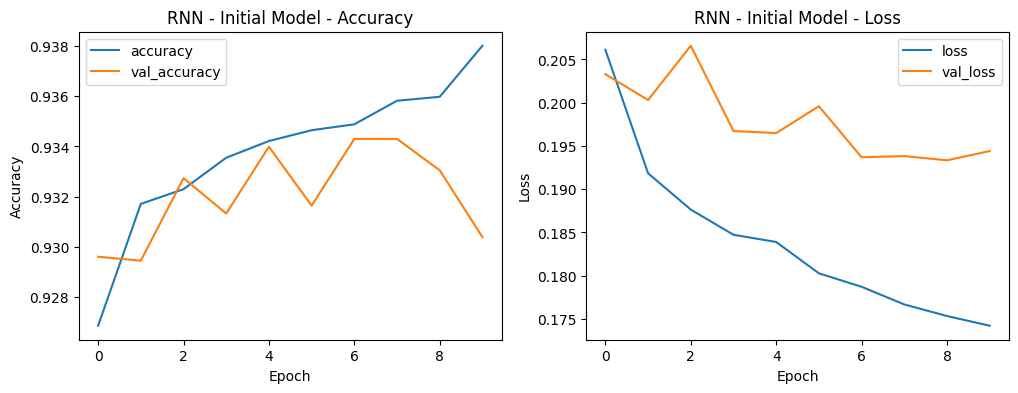

In [3]:



rnn_model = keras.Sequential([
    Input(shape=(), dtype=tf.string),
    Lambda(lambda x: embedding_layer(x)),
    Lambda(lambda x: tf.expand_dims(x, axis=1)),
    SimpleRNN(64, return_sequences=True, name="rnn_layer_1"),
    SimpleRNN(64, name="rnn_layer_2"),
    Dense(1, activation='sigmoid', name="output_layer")
])
rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history = rnn_model.fit(train_x, train_y, validation_data=(test_x, test_y), epochs=10, batch_size=32)
plot_training(rnn_history, "RNN - Initial Model")

#### 4. Hyparameter tuning/Experimentation
The experiments attempted to systematically examine the impact of architectural modifications and hyperparameter tuning on RNN performance in text classification. Various configurations were tested, including embedding layer adjustment, increasing the number of RNN units, and adding additional layers to test their impact on feature learning and sequence learning.

#### 4.1.Change the Embedding Layer

Epoch 1/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9248 - loss: 0.2301 - val_accuracy: 0.9293 - val_loss: 0.1980
Epoch 2/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9324 - loss: 0.1943 - val_accuracy: 0.9309 - val_loss: 0.1961
Epoch 3/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9368 - loss: 0.1874 - val_accuracy: 0.9274 - val_loss: 0.2031
Epoch 4/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9333 - loss: 0.1898 - val_accuracy: 0.9315 - val_loss: 0.1973
Epoch 5/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9346 - loss: 0.1877 - val_accuracy: 0.9315 - val_loss: 0.1914
Epoch 6/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9370 - loss: 0.1860 - val_accuracy: 0.9340 - val_loss: 0.1883
Epoch 7/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9407 - loss: 0.1771 - val_accuracy: 0.9356 - val_loss: 0.1858
Epoch 8/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9411 - loss: 0.170

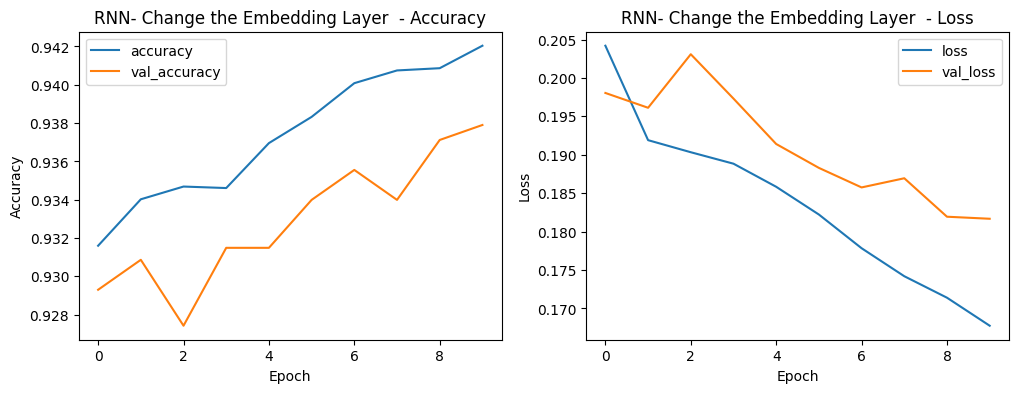

In [4]:
embedding_layer = hub.KerasLayer("https://tfhub.dev/google/nnlm-en-dim128/2", trainable=False)

rnn_model_embedding = keras.Sequential([
    Input(shape=(), dtype=tf.string),
    Lambda(lambda x: embedding_layer(x)),
    Lambda(lambda x: tf.expand_dims(x, axis=1)),
    SimpleRNN(64, return_sequences=True, name="rnn_layer_1"),
    SimpleRNN(64, name="rnn_layer_2"),
    Dense(1, activation='sigmoid', name="output_layer")
])


rnn_model_embedding.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history_embedding = rnn_model_embedding.fit(train_x, train_y, validation_data=(test_x, test_y), epochs=10, batch_size=16)
plot_training(rnn_history_embedding, "RNN- Change the Embedding Layer ")

#### 4.2. changing RNN units

Epoch 1/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9289 - loss: 0.2193 - val_accuracy: 0.9295 - val_loss: 0.1999
Epoch 2/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9330 - loss: 0.1973 - val_accuracy: 0.9304 - val_loss: 0.2021
Epoch 3/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9355 - loss: 0.1908 - val_accuracy: 0.9277 - val_loss: 0.1990
Epoch 4/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9366 - loss: 0.1866 - val_accuracy: 0.9307 - val_loss: 0.1987
Epoch 5/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9344 - loss: 0.1910 - val_accuracy: 0.9331 - val_loss: 0.1959
Epoch 6/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9376 - loss: 0.1867 - val_accuracy: 0.9335 - val_loss: 0.1964
Epoch 7/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9407 - loss: 0.1757 - val_accuracy: 0.9352 - val_loss: 0.1858
Epoch 8/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9399 - loss: 0.1773

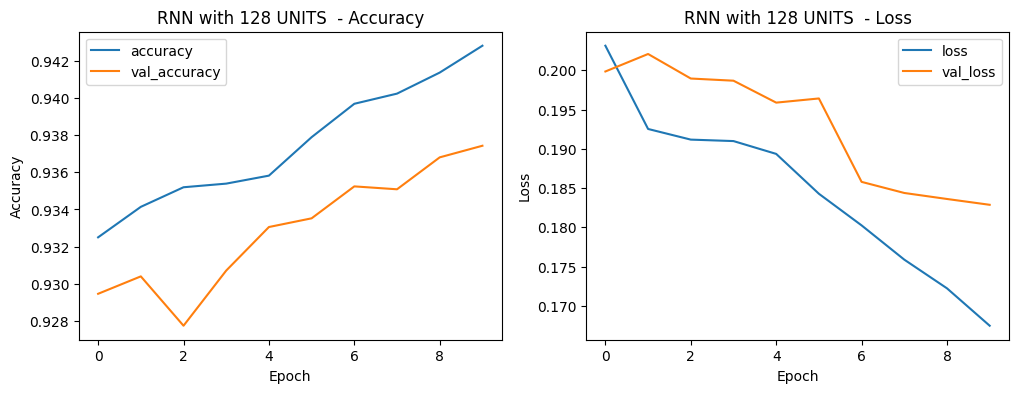

In [5]:
rnn_model_2 = keras.Sequential([
    Input(shape=(), dtype=tf.string),
    Lambda(lambda x: embedding_layer(x)),
    Lambda(lambda x: tf.expand_dims(x, axis=1)),
    SimpleRNN(128, return_sequences=True, name="rnn_layer_1"),
    SimpleRNN(128, name="rnn_layer_2"),
    Dense(1, activation='sigmoid', name="output_layer")
])


rnn_model_2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history_2 = rnn_model_2.fit(train_x, train_y, validation_data=(test_x, test_y), epochs=10, batch_size=16)
plot_training(rnn_history_2, "RNN with 128 UNITS ")

#### 4.3.Add more layers

Epoch 1/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9290 - loss: 0.2282 - val_accuracy: 0.9320 - val_loss: 0.2019
Epoch 2/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9338 - loss: 0.1940 - val_accuracy: 0.9332 - val_loss: 0.1965
Epoch 3/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9376 - loss: 0.1862 - val_accuracy: 0.9310 - val_loss: 0.1926
Epoch 4/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9398 - loss: 0.1800 - val_accuracy: 0.9346 - val_loss: 0.1875
Epoch 5/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9405 - loss: 0.1786 - val_accuracy: 0.9345 - val_loss: 0.1893
Epoch 6/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9395 - loss: 0.1766 - val_accuracy: 0.9363 - val_loss: 0.1908
Epoch 7/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9409 - loss: 0.1773 - val_accuracy: 0.9370 - val_loss: 0.1843
Epoch 8/10
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9461 - loss: 0.164

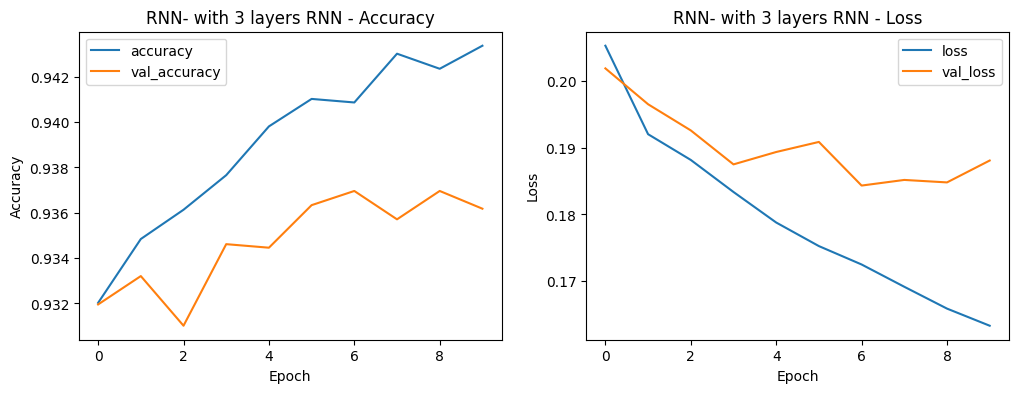

In [6]:
rnn_model_3 = keras.Sequential([
    Input(shape=(), dtype=tf.string),
    Lambda(lambda x: embedding_layer(x)),
    Lambda(lambda x: tf.expand_dims(x, axis=1)),
    SimpleRNN(64, return_sequences=True, name="rnn_layer_1"),
    SimpleRNN(64, return_sequences=True, name="rnn_layer_2"),
    SimpleRNN(64, name="rnn_layer_3"),
    Dense(1, activation='sigmoid', name="output_layer")
])


rnn_model_3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history_3 = rnn_model_3.fit(train_x, train_y, validation_data=(test_x, test_y), epochs=10, batch_size=16)
plot_training(rnn_history_3, "RNN- with 3 layers RNN")

#### 4.4. Tune Hyperparameters with different learning rates, batch sizes, and epochs

#### 4.4.1 Using Adam optimizer with a learning rate of 0.001,Increasing epochs to 20

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9135 - loss: 0.2666 - val_accuracy: 0.9332 - val_loss: 0.1987
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9346 - loss: 0.1938 - val_accuracy: 0.9301 - val_loss: 0.1989
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9340 - loss: 0.1913 - val_accuracy: 0.9299 - val_loss: 0.1978
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9344 - loss: 0.1933 - val_accuracy: 0.9274 - val_loss: 0.1969
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9349 - loss: 0.1881 - val_accuracy: 0.9337 - val_loss: 0.1900
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9366 - loss: 0.1862 - val_accuracy: 0.9346 - val_loss: 0.1906
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9415 - loss: 0.1749 - val_accuracy: 0.9313 - val_loss: 0.1933
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9400 - loss: 0.1767 - val_accuracy: 0.

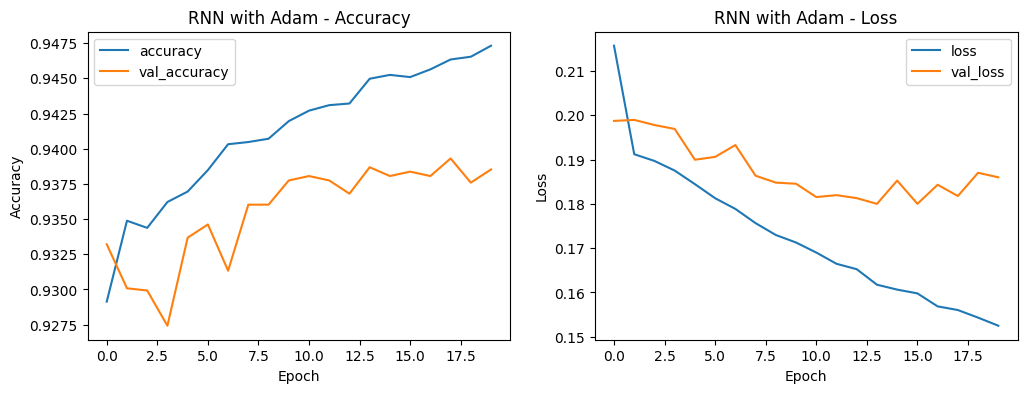

In [7]:
rnn_model_4 = keras.Sequential([
    Input(shape=(), dtype=tf.string),
    Lambda(lambda x: embedding_layer(x)),
    Lambda(lambda x: tf.expand_dims(x, axis=1)),
    SimpleRNN(64, return_sequences=True, name="rnn_layer_1"),
    SimpleRNN(64, return_sequences=True, name="rnn_layer_2"),
    SimpleRNN(64, name="rnn_layer_3"),
    Dense(1, activation='sigmoid', name="output_layer")
])

optimizer = keras.optimizers.Adam(learning_rate=0.001)

rnn_model_4.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
rnn_history_4 = rnn_model_4.fit(train_x, train_y, validation_data=(test_x, test_y), epochs=20, batch_size=64)
plot_training(rnn_history_4, "RNN with Adam")

#### 4.4.2 Using RMSprop optimizer with a learning rate of 0.001,Increasing epochs to 20

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9200 - loss: 0.2370 - val_accuracy: 0.9288 - val_loss: 0.2050
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9336 - loss: 0.1944 - val_accuracy: 0.9315 - val_loss: 0.1969
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9368 - loss: 0.1853 - val_accuracy: 0.9277 - val_loss: 0.2036
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9367 - loss: 0.1860 - val_accuracy: 0.9270 - val_loss: 0.2024
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9370 - loss: 0.1842 - val_accuracy: 0.9327 - val_loss: 0.1932
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9361 - loss: 0.1883 - val_accuracy: 0.9326 - val_loss: 0.1922
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9390 - loss: 0.1799 - val_accuracy: 0.9321 - val_loss: 0.1913
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9381 - loss: 0.1818 - val_accuracy: 0.

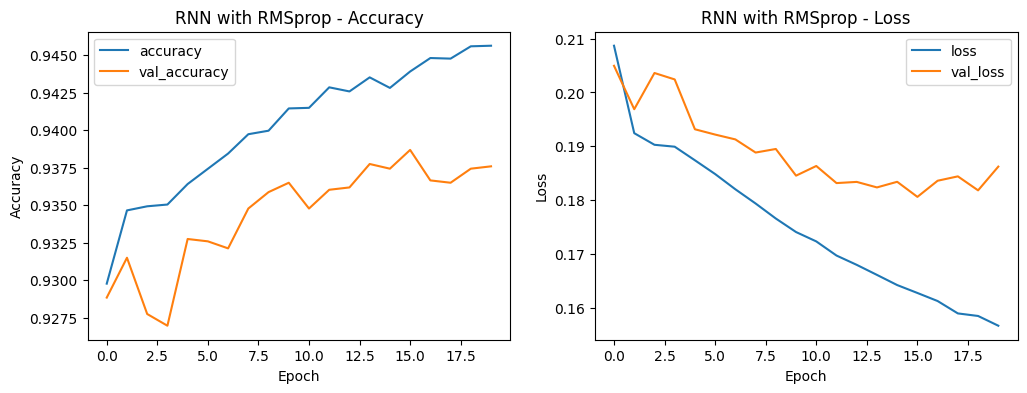

In [8]:
from tensorflow.keras.optimizers import RMSprop
rnn_model_4_RMSprop = keras.Sequential([
    Input(shape=(), dtype=tf.string),
    Lambda(lambda x: embedding_layer(x)),
    Lambda(lambda x: tf.expand_dims(x, axis=1)),
    SimpleRNN(64, return_sequences=True, name="rnn_layer_1"),
    SimpleRNN(64, return_sequences=True, name="rnn_layer_2"),
    SimpleRNN(64, name="rnn_layer_3"),
    Dense(1, activation='sigmoid', name="output_layer")
])

optimizer = RMSprop(learning_rate=0.001)

rnn_model_4_RMSprop.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
rnn_history_4_RMSprop = rnn_model_4_RMSprop.fit(train_x, train_y, validation_data=(test_x, test_y), epochs=20, batch_size=64)
plot_training(rnn_history_4_RMSprop, "RNN with RMSprop")

#### 4.4.3 Using Nadam optimizer with a learning rate of 0.001,Increasing epochs to 20

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9250 - loss: 0.2601 - val_accuracy: 0.9331 - val_loss: 0.2002
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9335 - loss: 0.1943 - val_accuracy: 0.9304 - val_loss: 0.1970
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9359 - loss: 0.1872 - val_accuracy: 0.9296 - val_loss: 0.1958
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9347 - loss: 0.1880 - val_accuracy: 0.9318 - val_loss: 0.1931
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9363 - loss: 0.1892 - val_accuracy: 0.9332 - val_loss: 0.1886
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9407 - loss: 0.1804 - val_accuracy: 0.9348 - val_loss: 0.1904
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9395 - loss: 0.1784 - val_accuracy: 0.9352 - val_loss: 0.1860
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9429 - loss: 0.1725 - val_accuracy: 0.

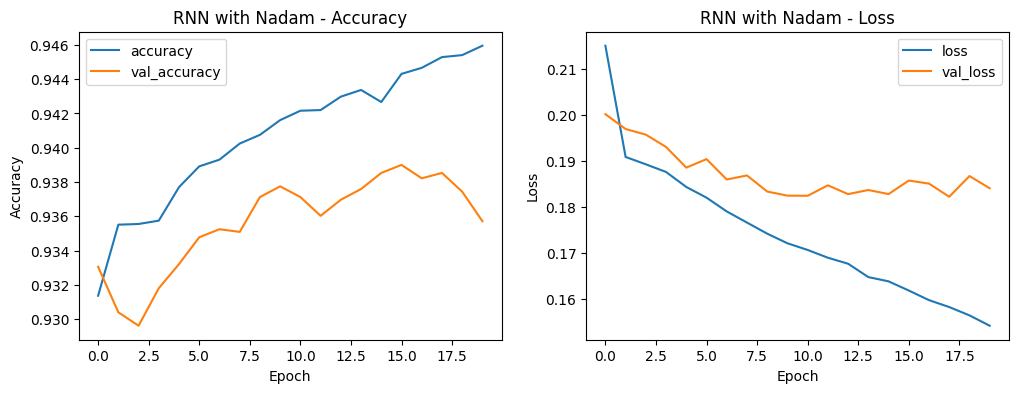

In [9]:
from tensorflow.keras.optimizers import Nadam
rnn_model_4_Nadam = keras.Sequential([
    Input(shape=(), dtype=tf.string),
    Lambda(lambda x: embedding_layer(x)),
    Lambda(lambda x: tf.expand_dims(x, axis=1)),
    SimpleRNN(64, return_sequences=True, name="rnn_layer_1"),
    SimpleRNN(64, return_sequences=True, name="rnn_layer_2"),
    SimpleRNN(64, name="rnn_layer_3"),
    Dense(1, activation='sigmoid', name="output_layer")
])

optimizer = Nadam(learning_rate=0.001)

rnn_model_4_Nadam.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
rnn_history_4_Nadam = rnn_model_4_Nadam.fit(train_x, train_y, validation_data=(test_x, test_y), epochs=20, batch_size=64)
plot_training(rnn_history_4_Nadam, "RNN with Nadam")

#### 4.5. Adding dropout layer

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9459 - loss: 0.1530 - val_accuracy: 0.9356 - val_loss: 0.1904
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9425 - loss: 0.1624 - val_accuracy: 0.9385 - val_loss: 0.1829
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9499 - loss: 0.1437 - val_accuracy: 0.9370 - val_loss: 0.1868
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9511 - loss: 0.1429 - val_accuracy: 0.9385 - val_loss: 0.1910
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9480 - loss: 0.1474 - val_accuracy: 0.9377 - val_loss: 0.1873
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9492 - loss: 0.1438 - val_accuracy: 0.9346 - val_loss: 0.1920
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9501 - loss: 0.1418 - val_accuracy: 0.9393 - val_loss: 0.1910
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9534 - loss: 0.1331 - val_accuracy: 0.

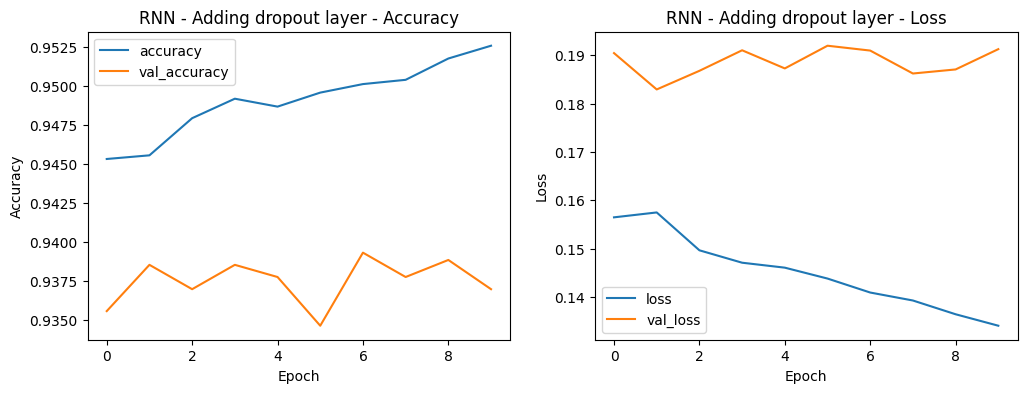

In [10]:
from tensorflow.keras.layers import Dropout
rnn_model_5 = keras.Sequential([
    Input(shape=(), dtype=tf.string),
    Lambda(lambda x: embedding_layer(x)),
    Lambda(lambda x: tf.expand_dims(x, axis=1)),
    SimpleRNN(64, return_sequences=True, name="rnn_layer_1"),
    Dropout(0.5),
    SimpleRNN(64, name="rnn_layer_2"),
    Dropout(0.5),
    Dense(1, activation='sigmoid', name="output_layer")
])



rnn_model_5.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history_4 = rnn_model_4.fit(train_x, train_y, validation_data=(test_x, test_y), epochs=10, batch_size=32)
plot_training(rnn_history_4, "RNN - Adding dropout layer")

#### 4.6. Adding BatchNormalization

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9549 - loss: 0.1261 - val_accuracy: 0.9351 - val_loss: 0.1935
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9560 - loss: 0.1231 - val_accuracy: 0.9374 - val_loss: 0.1898
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9569 - loss: 0.1239 - val_accuracy: 0.9362 - val_loss: 0.1941
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9589 - loss: 0.1212 - val_accuracy: 0.9356 - val_loss: 0.1953
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9549 - loss: 0.1218 - val_accuracy: 0.9387 - val_loss: 0.1939
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9588 - loss: 0.1123 - val_accuracy: 0.9390 - val_loss: 0.1938
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9599 - loss: 0.1113 - val_accuracy: 0.9348 - val_loss: 0.2026
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9605 - loss: 0.1087 - val_accuracy: 0.

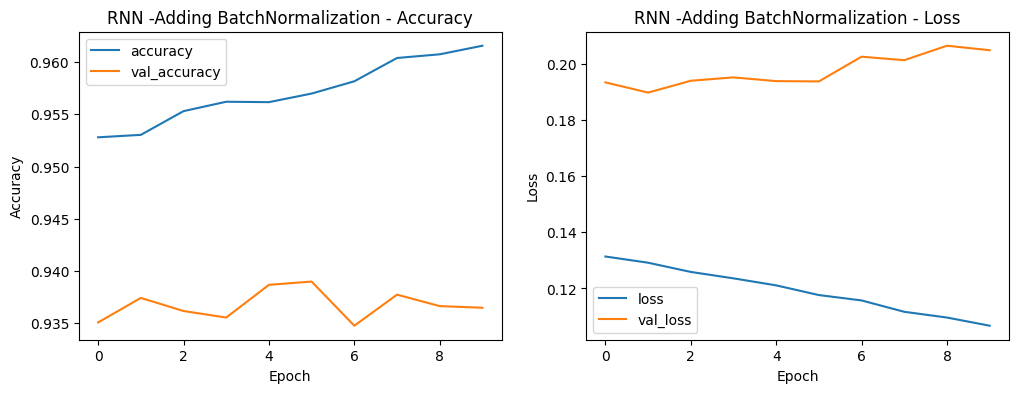

In [11]:
from tensorflow.keras.layers import BatchNormalization
rnn_model_5 = keras.Sequential([
    Input(shape=(), dtype=tf.string),
    Lambda(lambda x: embedding_layer(x)),
    Lambda(lambda x: tf.expand_dims(x, axis=1)),
    SimpleRNN(64, return_sequences=True, name="rnn_layer_1"),
    BatchNormalization(),
    SimpleRNN(64, name="rnn_layer_2"),
    BatchNormalization(),
    Dense(1, activation='sigmoid', name="output_layer")
])



rnn_model_5.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history_4 = rnn_model_4.fit(train_x, train_y, validation_data=(test_x, test_y), epochs=10, batch_size=32)
plot_training(rnn_history_4, "RNN -Adding BatchNormalization")

#### 5. Experiment Performance Analysis

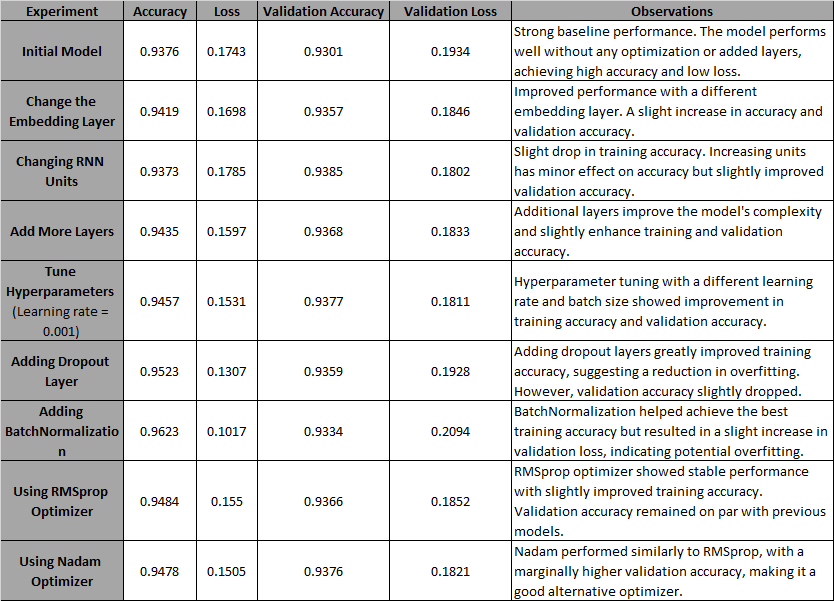

#### 6. Conclusion:

- Overall, layer addition, hyperparameter tuning, and usage of optimizers like RMSprop and Nadam assisted with small improvements in training and validation accuracy.
- BatchNormalization assisted in greatly enhanced training accuracy but loss of validation performance, which may be indicative of an overfitting issue. These findings suggest that an optimal combination of model architecture adjustment and hyperparameter tweaking, along with careful use of regularization, can assist in the creation of the top-performing model for sentiment analysis tasks.















